# Galactic Plane Sine Fit — Quadrants II & III

Companion analysis for the DSPIRA lesson
[*Determining a Velocity Curve of the Milky Way Galaxy*](https://wvurail.org/dspira/Astronomy_VelocityCurve_Overview),
**Part 1: Galactic Quadrants II & III Observation**.

You have measured the Doppler velocity of the 21 cm hydrogen line at several galactic
longitudes with the horn telescope. This notebook fits

$$v(\ell) = a \, \sin(b\,\ell + c) + v_\odot$$

to those measurements. A good fit is evidence that the Milky Way is **rotating**, and the
sign of the fit tells you which way.

**To use your own data:** replace the numbers in `quadrants_ii_iii_velocity_vs_longitude.csv`
with your class's measurements, then re-run the notebook from the top.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Load the observations

The data lives in a CSV next to this notebook so you can edit it without touching any code.
Each row is one pointing: the galactic longitude you observed, and the velocity you derived
from the Doppler shift of the HI peak.

In [2]:
DATA_FILE = "quadrants_ii_iii_velocity_vs_longitude.csv"

longitude_deg, velocity = np.loadtxt(DATA_FILE, delimiter=",", skiprows=1, unpack=True)
longitude_rad = np.radians(longitude_deg)

for l, v in zip(longitude_deg, velocity):
    print(f"  l = {l:5.1f} deg    v = {v:6.1f} km/s")

  l = 160.0 deg    v =   32.3 km/s
  l = 150.0 deg    v =   42.9 km/s
  l = 140.0 deg    v =   51.3 km/s
  l = 130.0 deg    v =   61.9 km/s
  l = 120.0 deg    v =   66.1 km/s
  l = 110.0 deg    v =   64.0 km/s
  l =  90.0 deg    v =   51.3 km/s


## 2. Fit a sine curve

`V_SUN` is the Sun's motion with respect to the Local Standard of Rest along this part of
the plane; the lesson treats it as a known offset rather than something we fit for. The
three free parameters are the amplitude `a`, the angular frequency `b`, and the phase `c`.

In [3]:
V_SUN = -9.4  # km/s, solar motion offset assumed by the lesson


def sine_model(longitude_rad, a, b, c):
    return a * np.sin(b * longitude_rad + c) + V_SUN


params, covariance = curve_fit(
    sine_model, longitude_rad, velocity, p0=[30, 2, 0]
)
a, b, c = params
errors = np.sqrt(np.diag(covariance))

print(f"amplitude a = {a:8.3f} +/- {errors[0]:.3f} km/s")
print(f"frequency b = {b:8.3f} +/- {errors[1]:.3f}")
print(f"phase     c = {c:8.3f} +/- {errors[2]:.3f} rad")

amplitude a =  -74.077 +/- 1.062 km/s
frequency b =    1.306 +/- 0.051
phase     c =    2.063 +/- 0.122 rad


## 3. Plot the data and the fit

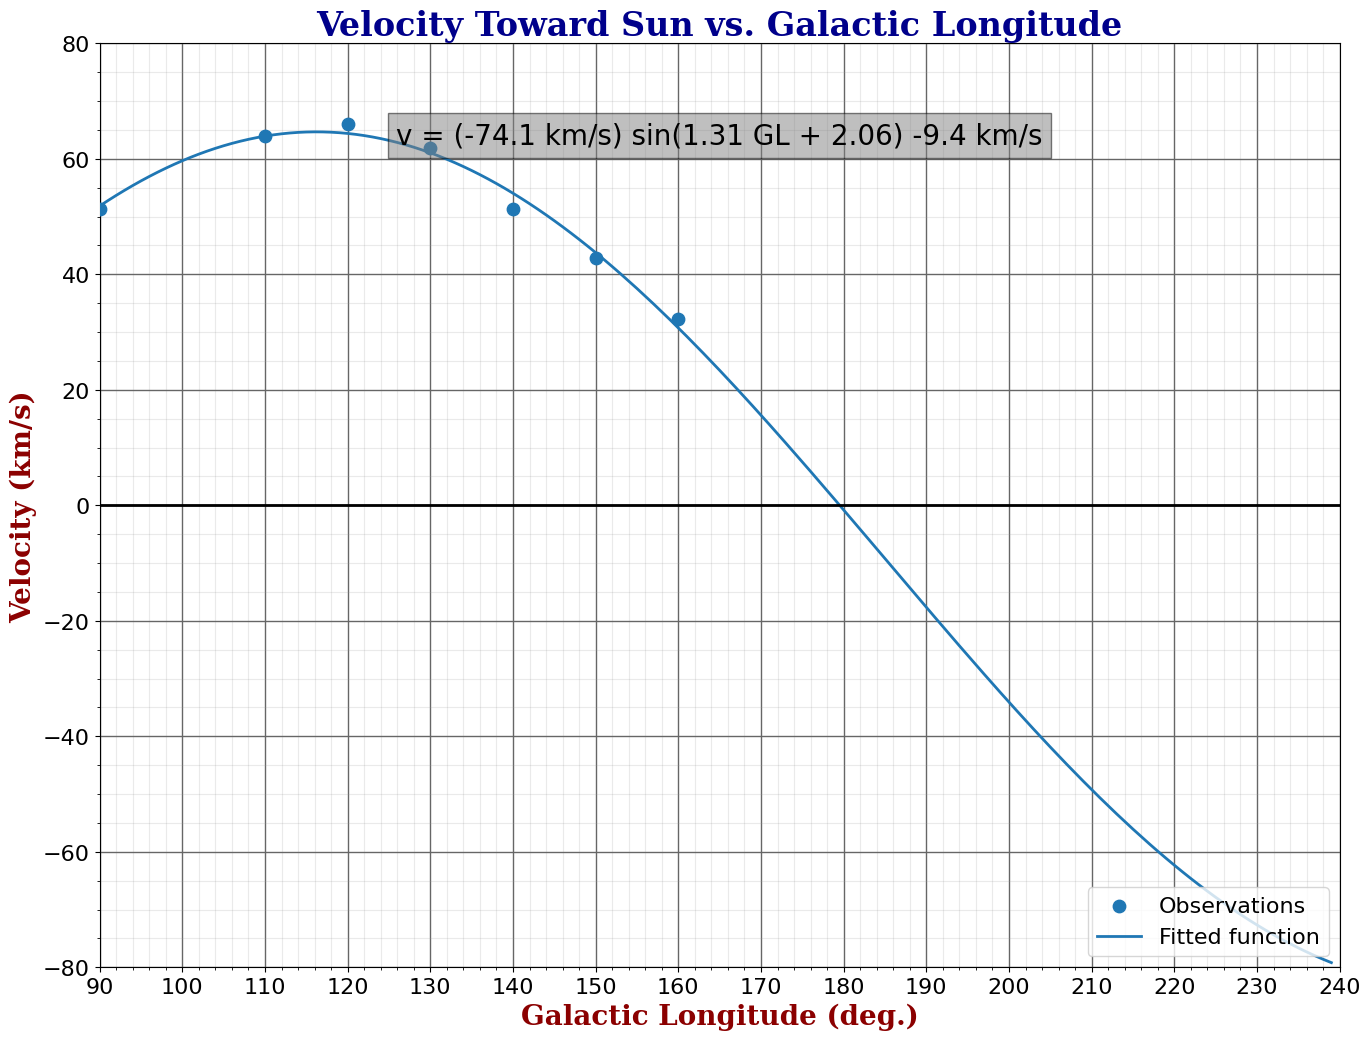

In [4]:
model_deg = np.arange(90, 240, 1.0)
model_velocity = sine_model(np.radians(model_deg), *params)

title_font = {"family": "serif", "color": "darkblue", "weight": "bold", "size": 24}
label_font = {"family": "serif", "color": "darkred", "weight": "bold", "size": 20}

fig, ax = plt.subplots(figsize=(16, 12))

ax.scatter(longitude_deg, velocity, s=80, zorder=3, label="Observations")
ax.plot(model_deg, model_velocity, lw=2, label="Fitted function")
ax.axhline(0, lw=2, color="black")

ax.set_title("Velocity Toward Sun vs. Galactic Longitude", fontdict=title_font)
ax.set_xlabel("Galactic Longitude (deg.)", fontdict=label_font)
ax.set_ylabel("Velocity (km/s)", fontdict=label_font)
ax.set_xlim(90, 240)
ax.set_ylim(-80, 80)

ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(5))
ax.tick_params(labelsize=16)
ax.minorticks_on()
ax.grid(True, which="major", color="#666666", linestyle="-", linewidth=1)
ax.grid(True, which="minor", color="#999999", linestyle="-", alpha=0.2)

fit_info = f"v = ({a:.3g} km/s) sin({b:.3g} GL + {c:.3g}) {V_SUN:+.1f} km/s"
ax.text(
    0.5, 0.9, fit_info, transform=ax.transAxes, fontsize=20,
    ha="center", va="center",
    bbox=dict(boxstyle="square", facecolor="gray", alpha=0.5),
)
ax.legend(fontsize=16, loc="lower right")

fig.savefig("galactic_plane_sine_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. What does this tell us?

Questions for students:

1. Every point in the sample data sits in **quadrant II** (galactic longitude 90-160
   degrees) and every velocity is positive - hydrogen there is approaching us. What
   would you expect the sign to be in quadrant III, and why?
2. The fitted curve crosses zero somewhere past 180 degrees, beyond where this data
   stops. What is physically happening at that longitude, and what observation would
   you need to make to check the prediction?
3. How much does the fitted amplitude change if you drop your least confident data
   point? What does that say about how many pointings you need?
